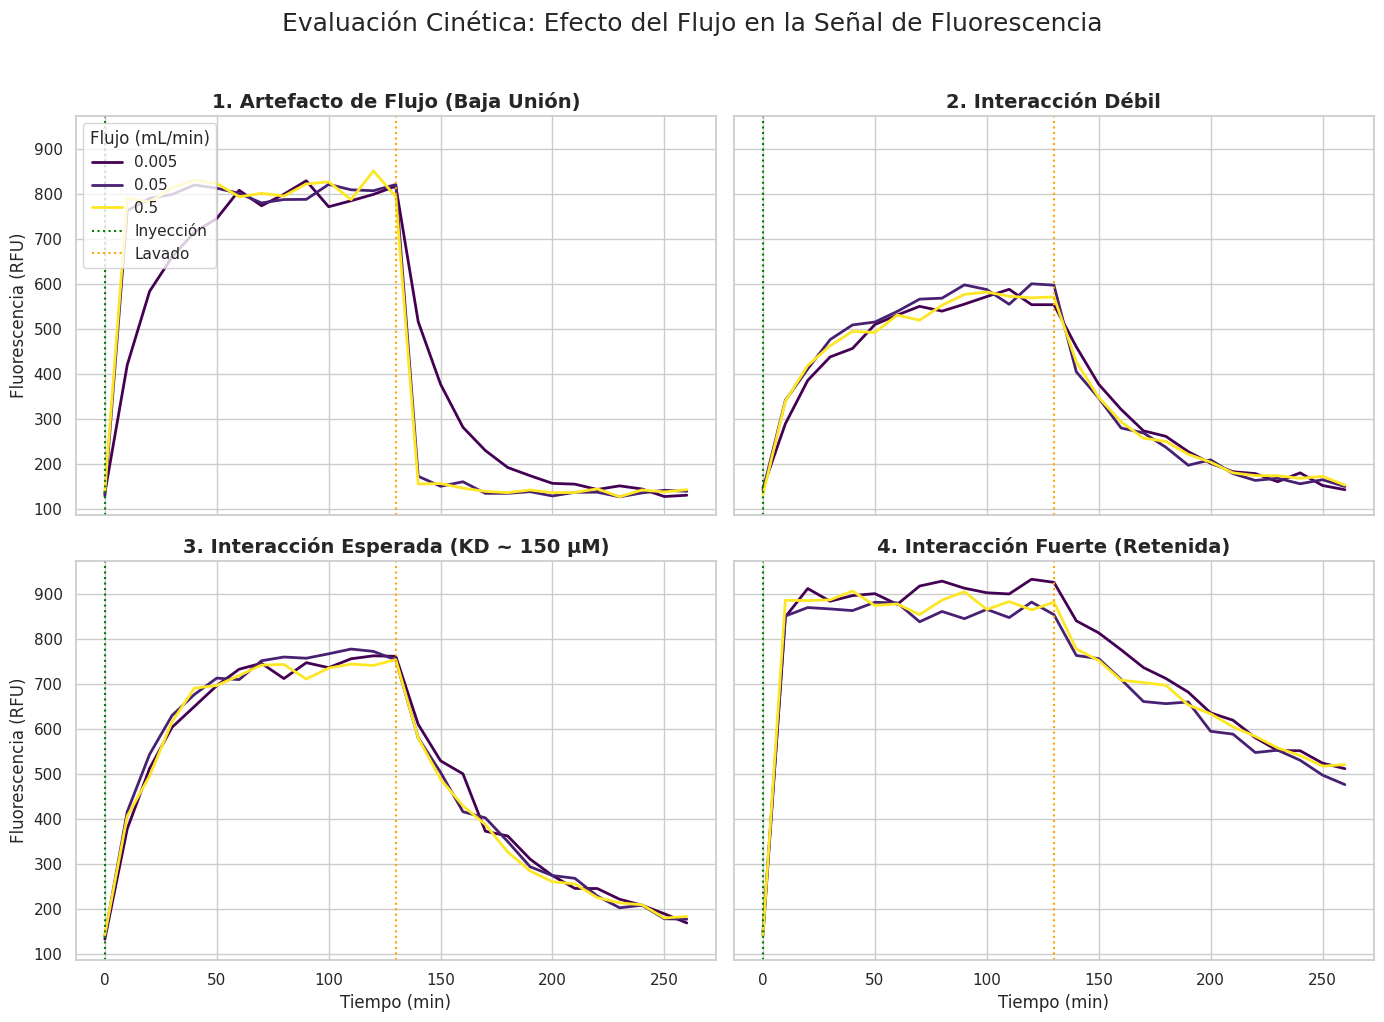

In [ ]:
# ==============================================================================
# SCRIPT 5: Análisis de Transporte y Número de Damköhler (Da)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos simulados
df = pd.read_csv('simulated_damkohler_scenario_data.csv')

# 2. Configurar el estilo visual
sns.set_theme(style="whitegrid")
escenarios = df['scenario'].unique()

# 3. Crear una figura con 4 subgráficos (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Diccionario para que los títulos se vean profesionales
titulos = {
    'bulk_flow_artifact_low_binding': '1. Artefacto de Flujo (Baja Unión)',
    'weak_reversible_interaction': '2. Interacción Débil',
    'expected_probe_biofilm_interaction': '3. Interacción Esperada (KD ~ 150 µM)',
    'strong_retained_interaction': '4. Interacción Fuerte (Retenida)'
}

# 4. Graficar cada escenario
for i, escenario in enumerate(escenarios):
    ax = axes[i]
    datos_escenario = df[df['scenario'] == escenario]

    # Graficamos la señal vs el tiempo, separando por color el flujo (flow_rate_mL_min)
    sns.lineplot(
        data=datos_escenario,
        x='time_min',
        y='fluorescence_noisy_RFU',
        hue='flow_rate_mL_min',
        palette='viridis', # Escala de colores (oscuro a claro)
        ax=ax,
        errorbar=None,
        linewidth=2
    )

    ax.set_title(titulos.get(escenario, escenario), fontsize=14, fontweight='bold')
    ax.set_xlabel('Tiempo (min)' if i >= 2 else '', fontsize=12)
    ax.set_ylabel('Fluorescencia (RFU)' if i % 2 == 0 else '', fontsize=12)

    # Buscar dinámicamente en qué minuto empezó el lavado en este dataset
    tiempo_lavado = datos_escenario[datos_escenario['phase'] == 'dissociation_buffer_wash']['time_min'].min()

    # Líneas verticales indicando las fases
    ax.axvline(x=0, color='green', linestyle=':', label='Inyección' if i==0 else "")
    if pd.notna(tiempo_lavado):
        ax.axvline(x=tiempo_lavado, color='orange', linestyle=':', label='Lavado' if i==0 else "")

    # Ajustar la leyenda para que no estorbe en todas las gráficas
    if i == 0:
        ax.legend(title='Flujo (mL/min)', loc='upper left')
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

plt.suptitle('Evaluación Cinética: Efecto del Flujo en la Señal de Fluorescencia', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

--- RESULTADOS DEL AJUSTE (Escenario Esperado) ---
k_obs: 0.0508 min^-1
k_off: 0.0236 min^-1
k_on:  135.7 M^-1 min^-1
K_D:   173.95 µM
K_A:   5748.69 M^-1


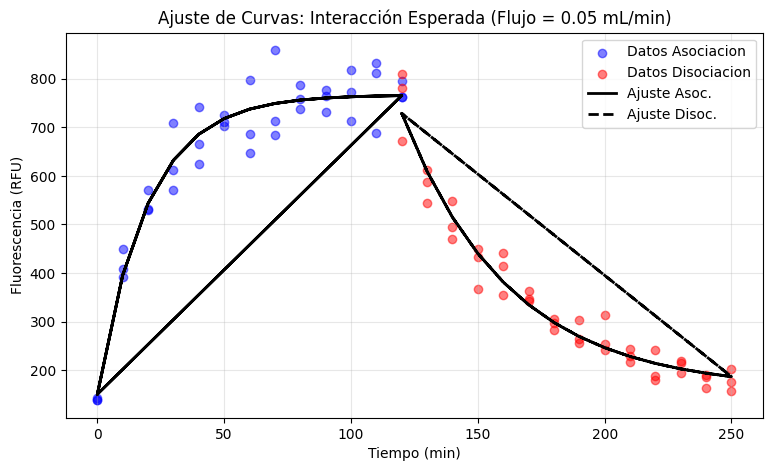

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Cargar los datos
df = pd.read_csv('eduardo_simulated_damkohler_scenario_data.csv')

# 2. Aislar el escenario "Interacción Esperada" y un flujo intermedio (0.05 mL/min)
escenario_esperado = df[(df['scenario'] == 'expected_probe_biofilm_interaction') &
                        (df['flow_rate_mL_min'] == 0.05)]

# Separar las fases según la columna del CSV
fase_asoc = escenario_esperado[escenario_esperado['phase'] == 'association_probe_injection']
fase_disoc = escenario_esperado[escenario_esperado['phase'] == 'dissociation_buffer_wash']

# Concentración de la sonda para este experimento (en Molar)
L_molar = fase_asoc['probe_concentration_M'].iloc[0]

# ==========================================
# 3. AJUSTE DE ASOCIACIÓN
# ==========================================
def ec_asoc(t, Y_max, k_obs, Fondo):
    return (Y_max - Fondo) * (1 - np.exp(-k_obs * t)) + Fondo

t_asoc = fase_asoc['phase_time_min'].values
fl_asoc = fase_asoc['fluorescence_noisy_RFU'].values

# Suposiciones iniciales [Y_max, k_obs, Fondo]
popt_asoc, _ = curve_fit(ec_asoc, t_asoc, fl_asoc, p0=[800, 0.1, 100])
Y_max_calc, k_obs_calc, Fondo_asoc_calc = popt_asoc

# ==========================================
# 4. AJUSTE DE DISOCIACIÓN
# ==========================================
def ec_disoc(t, Y0, k_off, Fondo):
    return (Y0 - Fondo) * np.exp(-k_off * t) + Fondo

t_disoc = fase_disoc['phase_time_min'].values
fl_disoc = fase_disoc['fluorescence_noisy_RFU'].values

# Suposiciones iniciales [Y0, k_off, Fondo]
popt_disoc, _ = curve_fit(ec_disoc, t_disoc, fl_disoc, p0=[800, 0.1, 100])
Y0_calc, k_off_calc, Fondo_disoc_calc = popt_disoc

# ==========================================
# 5. CÁLCULO DE PARÁMETROS CINÉTICOS FINALES
# ==========================================
k_on_calc = (k_obs_calc - k_off_calc) / L_molar
Kd_molar = k_off_calc / k_on_calc
Kd_uM = Kd_molar * 1_000_000  # Convertir a micromolar para comparar con el asesor
Ka_calc = 1 / Kd_molar

print("--- RESULTADOS DEL AJUSTE (Escenario Esperado) ---")
print(f"k_obs: {k_obs_calc:.4f} min^-1")
print(f"k_off: {k_off_calc:.4f} min^-1")
print(f"k_on:  {k_on_calc:.1f} M^-1 min^-1")
print(f"K_D:   {Kd_uM:.2f} µM")
print(f"K_A:   {Ka_calc:.2f} M^-1")

# ==========================================
# 6. GRÁFICA DE VERIFICACIÓN
# ==========================================
plt.figure(figsize=(9, 5))

# Graficar datos ruidosos simulados
plt.scatter(t_asoc, fl_asoc, color='blue', alpha=0.5, label='Datos Asociacion')
plt.scatter(t_disoc + t_asoc.max(), fl_disoc, color='red', alpha=0.5, label='Datos Disociacion')

# Graficar los ajustes matemáticos
plt.plot(t_asoc, ec_asoc(t_asoc, *popt_asoc), color='black', linewidth=2, label='Ajuste Asoc.')
plt.plot(t_disoc + t_asoc.max(), ec_disoc(t_disoc, *popt_disoc), color='black', linewidth=2, linestyle='--', label='Ajuste Disoc.')

plt.title('Ajuste de Curvas: Interacción Esperada (Flujo = 0.05 mL/min)')
plt.xlabel('Tiempo (min)')
plt.ylabel('Fluorescencia (RFU)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()